# Train logistic regression model (t+3 target)
Train a logistic regression classifier on `data/processed/log_reg_t3`, using `target_t+3` as the label and all columns except the target, `client_nr`, and `yearmonth` as features.

Raw-magnitude features are standardized inside the pipeline (already-scaled z-scores/slopes and one-hot dummies are passed through), and `class_weight="balanced"` handles the rare positive class. Hyperparameters (`C`, `penalty`) are tuned with **Optuna**, maximizing PR-AUC on the validation split. The classification threshold is **not** tuned automatically: it is chosen manually below by inspecting the validation precision-recall curve.

In [1]:
import sys
from pathlib import Path

import pandas as pd

# walk up to the project root so this notebook works from its subfolder
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "models").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT / "models"))

import train_logistic_regression
from train_logistic_regression import (
    evaluate_all_splits,
    load_split,
    plot_precision_recall_curve,
    save_model,
    train_model,
)

HORIZON = "t3"
train_logistic_regression.set_horizon(HORIZON)
TARGET_COLUMN = train_logistic_regression.TARGET_COLUMN

c:\Users\SVisbee\Repos\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using dataset log_reg_t3 with target 'target_t+3'


## Tune hyperparameters and train

In [2]:
model, feature_columns, trials_df = train_model(n_trials=50)

Train observations: 18,803
Validation observations: 3,763
Number of features: 47

Class distribution in training data:
  Negative: 17,456
  Positive: 1,347


Best trial: 18. Best value: 0.137036: 100%|██████████| 50/50 [05:17<00:00,  6.36s/it]



Best validation PR-AUC: 0.1370
Best hyperparameters:
  C: 1.0
  penalty: l2


In [3]:
trials_df.sort_values("value", ascending=False).head(10)

,number,value,datetime_start,datetime_complete,duration,params_C,params_penalty,state
25,25,0.137036,2026-08-31 00:23:03.131202,2026-08-31 00:23:14.094520,0 days 00:00:10.963318,1.0,l2,COMPLETE
32,32,0.137036,2026-08-31 00:24:03.326895,2026-08-31 00:24:14.304842,0 days 00:00:10.977947,1.0,l2,COMPLETE
22,22,0.137036,2026-08-31 00:22:32.969232,2026-08-31 00:22:42.657693,0 days 00:00:09.688461,1.0,l2,COMPLETE
23,23,0.137036,2026-08-31 00:22:42.661413,2026-08-31 00:22:53.151330,0 days 00:00:10.489917,1.0,l2,COMPLETE
24,24,0.137036,2026-08-31 00:22:53.156384,2026-08-31 00:23:03.127348,0 days 00:00:09.970964,1.0,l2,COMPLETE
26,26,0.137036,2026-08-31 00:23:14.096148,2026-08-31 00:23:24.588634,0 days 00:00:10.492486,1.0,l2,COMPLETE
29,29,0.137036,2026-08-31 00:23:32.894180,2026-08-31 00:23:43.111960,0 days 00:00:10.217780,1.0,l2,COMPLETE
30,30,0.137036,2026-08-31 00:23:43.111960,2026-08-31 00:23:53.387429,0 days 00:00:10.275469,1.0,l2,COMPLETE
31,31,0.137036,2026-08-31 00:23:53.391371,2026-08-31 00:24:03.324899,0 days 00:00:09.933528,1.0,l2,COMPLETE
33,33,0.137036,2026-08-31 00:24:14.306763,2026-08-31 00:24:24.724965,0 days 00:00:10.418202,1.0,l2,COMPLETE


## Select the classification threshold
Inspect the precision-recall curve on the **validation** split (train would be optimistic, test must stay untouched) and pick the threshold matching the business objective.

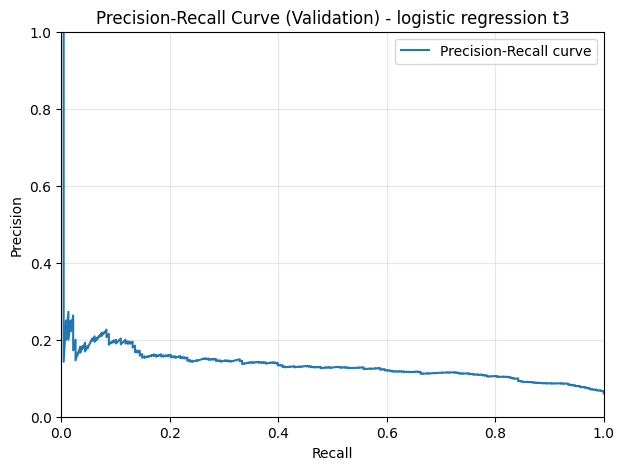

In [4]:
val_df = load_split("val")

threshold_table = plot_precision_recall_curve(
    model,
    val_df,
    feature_columns,
    title=f"Precision-Recall Curve (Validation) - logistic regression {HORIZON}",
)

In [6]:
# inspect candidate operating points to pick a threshold
threshold_table = threshold_table.sort_values(by="recall", ascending=False)
threshold_table[threshold_table["precision"] >= 0.25].head(20)

,threshold,precision,recall
3743,0.907585,0.250000,0.021930
3744,0.911032,0.263158,0.021930
3747,0.920758,0.250000,0.017544
3751,0.931433,0.250000,0.013158
3752,0.936920,0.272727,0.013158
3755,0.947026,0.250000,0.008772
3759,0.990406,0.250000,0.004386
3760,0.993807,0.333333,0.004386
3761,0.994613,0.500000,0.004386
3762,0.995381,1.000000,0.004386


### Chosen threshold
Set `SELECTED_THRESHOLD` below based on the curve and table above.

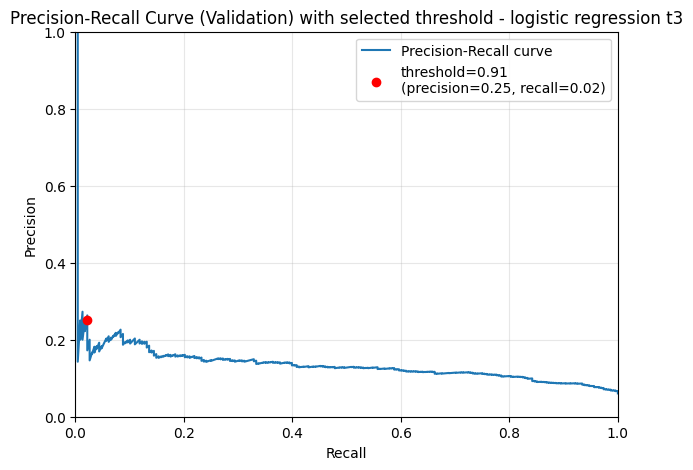

In [7]:
SELECTED_THRESHOLD = 0.907585

plot_precision_recall_curve(
    model,
    val_df,
    feature_columns,
    threshold=SELECTED_THRESHOLD,
    title=f"Precision-Recall Curve (Validation) with selected threshold - logistic regression {HORIZON}",
);

## Final evaluation

In [8]:
evaluate_all_splits(model, feature_columns, threshold=SELECTED_THRESHOLD)

,pr_auc,precision,recall,f1,precision_at_k (k=90),recall_at_k (k=90)
train,0.132073,0.250000,0.005197,0.010182,0.255556,0.017075
val,0.137036,0.263158,0.021930,0.040486,0.211111,0.083333
test,0.152809,0.255814,0.040293,0.069620,0.222222,0.073260


## Save the model
Persist the fitted model together with its feature list and chosen threshold, so it can be reloaded for comparison and inference.

In [9]:
save_model(model, feature_columns, threshold=SELECTED_THRESHOLD)

Saved model to C:\Users\SVisbee\Repos\Credit_prediction_case\models\artifacts\log_reg_t3.joblib


WindowsPath('C:/Users/SVisbee/Repos/Credit_prediction_case/models/artifacts/log_reg_t3.joblib')